In [8]:
import sys
sys.path.append('..')
import os
# os.chdir("./playgrounds/")

In [9]:
from classes.PnP_class import *
from NECTR_model.model_loader import *

#### Image object
- **image_path**: Path to the image  
- **forward_model_name**: Name of the forward model  
- **forward_model_args**: Arguments for the forward model  
- **noise_level**: Noise level to be added to the image  
- **kernel_path**: Path to the kernel file (Custom forward model through convolution; not implemented yet)  
- **color_mode**: `'RGB'` for color images, `'L'` for grayscale images  
- **crop**: `True` to crop the image to 256x256  
- **seed_val**: Seed value for reproducibility  
- **save_path**: Path to save the results; default is `./results/`  

> **Note**: Only the method `get_images()` will save the images when called with `save=True`.

> The detailed description of the attributes can be found at the end of the notebook.

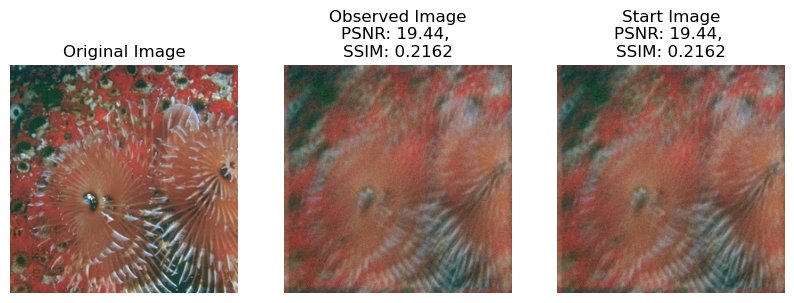

Image shape: (256, 256, 3)


In [10]:
image_id = 'CBSD10/0001'
color_mode = 'RGB'
algo = 'HQS'
device = 'cuda:0'
application_type = 'deblurring'
image_path = "../images/{}.png".format(image_id)
denoiser_name = 'NECTR'
save_path = "../Experiments/Exp1a/{}/{}/{}/{}/".format(
    image_id, application_type, denoiser_name, algo)
my_image = img_PnP(image_path, forward_model_name=application_type,
                         forward_model_args={'scale_factor': 1,
                                             'kernel_id': 7, 'device': device},
                         noise_level=0.03, color_mode=color_mode, save_path=save_path, crop=True)
_ = my_image.get_images(plot=True, save=True)
print("Image shape:", my_image.image.shape)



In [11]:
MODEL_CHOICE = 'model1'
denoiser_NECTR = load_model(
    config_folder="../NECTR_model/configs_{}".format(MODEL_CHOICE),
                            window_rad=7, #T[n]
                            device=device, model_choice=MODEL_CHOICE
                            ).to(device) ### Model Object
run_NECTR = NECTR ### Model Infer Method

Using latest checkpoint: ../NECTR_model/configs_model1/checkpoints/NECTR_iter_300000.pth
Initializing model 'NECTR_models1' on cuda:0...
self.proj: ModuleList(
  (0): ModuleList(
    (0): Conv2d(256, 128, kernel_size=(1, 1), stride=(1, 1))
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (2): LeakyReLU(negative_slope=0.01)
  )
  (1): ModuleList(
    (0): Conv2d(128, 64, kernel_size=(1, 1), stride=(1, 1))
    (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (2): LeakyReLU(negative_slope=0.01)
  )
  (2): ModuleList(
    (0): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1))
    (1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
    (2): LeakyReLU(negative_slope=0.01)
  )
)
Loading checkpoint: ../NECTR_model/configs_model1/checkpoints/NECTR_iter_300000.pth
Model loaded successfully!
  Iteration: 300000
  Loss: 0.000606
  Total parameters: 907,840
  Set model window radius to: 7 (from 7)
Model loaded successfully!
  Iteration: 300000
  Loss: 0.000606
 

In [12]:
#### compute reference image z
denoiser_args = {
    'reference_image': my_image.observed,  # Reference image is the observed image
                  'h': 0.03} ### Denoiser Args
algo_params={'transpose': False, 'name': 'FBS', 'step_size': 2.0, 'clip': False}
algo_params={'transpose': False, 'name': 'HQS', 'step_size': 5.0, 'clip': False}
warm_up_iters = 100

100%|██████████| 1/1 [00:01<00:00,  1.17s/it]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


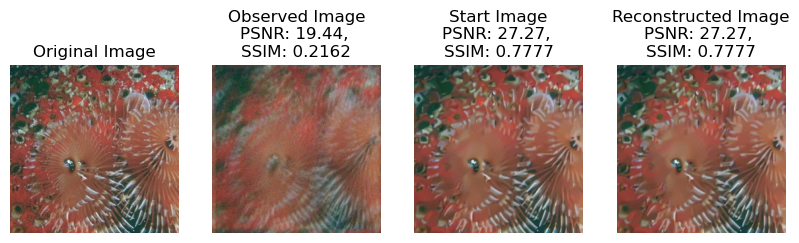

In [13]:
warm_up_iters = 20
denoiser_args['h'] = 8.0/255.0
algo_params['step_size'] = 6.5
for i in range(warm_up_iters):
    my_image.PnP(denoiser=run_NECTR,
             denoiser_args=denoiser_args,
             denoiser_object=denoiser_NECTR,
             num_iterations=1,
                plot_graphs=True,
                plot_interval=101,
                algo_params=algo_params,
        )
    denoiser_args['reference_image'] = my_image.reconstruction
    my_image.start_image = my_image.reconstruction.copy()

_ = my_image.get_images(plot=True, save=True)

 99%|█████████▉| 100/101 [01:53<00:01,  1.14s/it]Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


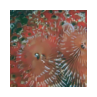

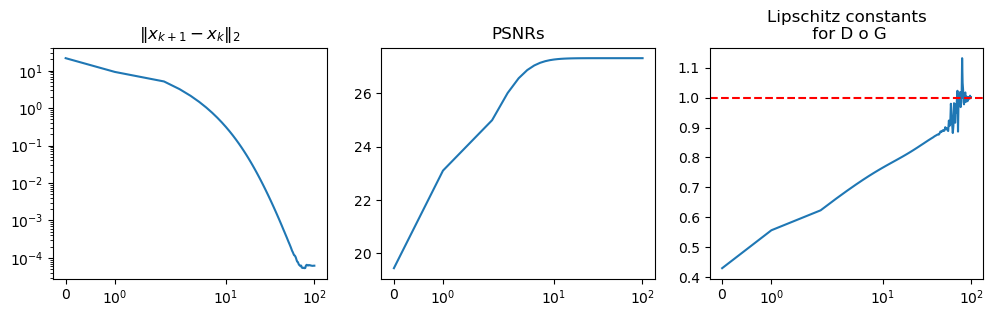

100%|██████████| 101/101 [01:55<00:00,  1.14s/it]

Iteration: 100
PSNR: 27.32278292563887
Norm: 6.204557e-05
-------------------------------


In [14]:
my_image.start_image = my_image.observed.copy()
my_image.PnP(denoiser=run_NECTR,
             denoiser_args=denoiser_args,
             denoiser_object=denoiser_NECTR,
             num_iterations=101,
                plot_graphs=True,
                plot_interval=100,
                algo_params=algo_params,
        )